# OGM and RL #

## Defining the Environment ##

In [56]:
# Import pacakge
import matplotlib.pyplot as plt
import random
from copy import copy
import numpy as np
import math
from collections import defaultdict

# Define Environment
class Environment ():
    """
    The environment models the external system (that is the world) with which the agent interacts
    """
   # Make a list to store all actions
    ACTIONS = ["stop", "retrieve"]

    # Create a dict to classify all q(s) into trauma or non-trauma memory
    # the goal is to recall as many q as possible in the chunk "non-trauma"
    MEMORY_CHUNK = [
    {'isa': "trauma", "actor": ["man"], "action": ["shoot", "run"], "object": ["dogs"],"time": ["evening", "summer"],"location":["street"], "valence":["neagtive"]},
    {'isa': "other", "actor": ["friends"], "action": ["study"], "object": ["trees"],"time": ["morning", "spring"], "location":["school", "classroom"], "valence":["postive"]},
    {'isa': "target", "actor": ["family", "dogs", "kids"], "action": ["run", "picnic"], "object": ["forest", "flower"],"time": ["summer", "morning"],"location": ["restaurant"], "valence":["postive"]}]
    #{'isa': "event4", "action": ["fail"], "object": ["test"], "time": ["high school"], "valence": ["negative"]},
    #{'isa': "event5", "actor": ["family"], "action": ["eat"],"location": ["home"], "time": ["evening", "last week"],"valence": ["neutral"]}]

    MEMORY_AROUSAL = {'trauma': 20, 'other': 5, 'target': 5, "event4": 0, "event5": 5, "final": 0}
    MEMORY_REWARD = {'trauma': -100, 'other': 10, 'target': 10, "event4": 0, "event5": 20, "final": 0}
    CHUNK_CREATE_TIME = {'trauma': 50, 'other': 50, 'target': 50, "event4": 0, "event5": 0, "final": 0}

    CHUNK = {}
    for i in range(len(MEMORY_CHUNK)):
      for key, value in MEMORY_CHUNK[i].items():
        if key not in ['isa', 'valence']:
          CHUNK.setdefault(MEMORY_CHUNK[i]['isa'], []).extend(value)
          #CHUNK[MEMORY_CHUNK[i]['isa']].append(None)


    CHUNK_AROUSAL = {}
    for key, value in CHUNK.items():
      for item in value:  # Iterate through items in the list
          CHUNK_AROUSAL[item] = CHUNK_AROUSAL.get(item, 0) + MEMORY_AROUSAL[key] / (len(value))


    REWARD_TRANSITION = {}
    for key, value in CHUNK.items():
      for item in value:  # Iterate through items in the list
          REWARD_TRANSITION[item] = REWARD_TRANSITION.get(item, 0) + MEMORY_REWARD[key] / (len(value))

    TIME_HISTORY = {}
    for key, value in CHUNK.items():
      for item in value:  # Iterate through items in the list
        current_create_time = TIME_HISTORY.get(item, 0)
        if isinstance(current_create_time, list):  # if the value is already a list, get the last element for comparison
            current_create_time = current_create_time[-1]
        TIME_HISTORY.setdefault(item, []).append(max(current_create_time, CHUNK_CREATE_TIME[key]))


    #INITIAL_STATE = random.choice([state for sublist in CHUNK.values() for state in sublist if key == "target"])
    INITIAL_STATE = "picnic"
    def __init__(self, w=1, d=0.5) -> None:
        """
        Initializes the environment
        """

        #self.INITIAL_STATE = random.choice([state for sublist in self.CHUNK.values() for state in sublist if state is not None])
        #self.retrieval_history = defaultdict(lambda: (0, 0.5))  # default t0 = 0, decay = 1
        self.state = self.INITIAL_STATE
        self.current = 100
        self.SA = {}
        self.visited_states = set()
        self.memory = defaultdict(int)
        self.decay_rate = d
        self.w = w
        self.base_act_dict = defaultdict(float)
        self.retrieval_history = []



    def base_activation(self, state, current_time):
      if state in [item for sublist in self.CHUNK.values() for item in sublist]:
        t_list = self.TIME_HISTORY[state]


        b_act = 0.0
        for t in t_list:
            time_diff = min(current_time - t, 100)
            time_diff = max(time_diff, 0)
            b_act += (time_diff+0.00001) ** (-self.decay_rate)
        self.TIME_HISTORY[state].append(current_time)
        return math.log(b_act + 1e-5)


    def spreading_activation(self, state1, state2):
        """
        Calculate the spread activation between two values in the global CHUNK dictionary.

        Parameters:
            state1 (str): The first value to compare.
            state2 (str): The second value to compare.

        Returns:
            float: The spread activation value.
        """

        # Find base level arousal for state2
        #intensity = self.CHUNK_AROUSAL[state2]
        #+ self.base_activation(state2, self.t)

        # Find which lists in the CHUNK contain value1 and value2
        chunks_containing_state1 = {key for key, values in self.CHUNK.items() if state1 in values}
        chunks_containing_state2 = {key for key, values in self.CHUNK.items() if state2 in values}


        if not chunks_containing_state1 or not chunks_containing_state2:
            return 0

        # Calculate overlap and union
        overlap = len(chunks_containing_state1.intersection(chunks_containing_state2))
        total_unique = len(chunks_containing_state1)

        # Calculate spread activation
        spreading_activation = overlap / total_unique if total_unique > 0 else 0

        spreading_activation *= self.w
        #spreading_activation += intensity

        return spreading_activation


    def reward_transition(self, s1):
        """Reward transitions. """
        if s1 == None:
            return 0
        else:
            return self.REWARD_TRANSITION.get(s1, 0)



    def get_max_sa_state(self, s0, chunk_states):
        sa_values = [
            self.SA.get((s0, state), 0)
            for state in chunk_states
            if state != s0 and state not in self.visited_states
        ]
        if sa_values:
            max_sa = max(sa_values)
            max_states = [
                state for (s0_key, state), value in self.SA.items()
                if value == max_sa
            ]
            return random.choice(max_states)
        return None


    def state_transition(self, a0, s0, current_time):
        """
        Get the next state (memory) based on the current action and state.
        """

        spread_activations = defaultdict(float)
        current_time = self.current

        if a0 == "stop":
            return None

        elif a0 == "retrieve":

            if (s0 in [item for sublist in self.CHUNK.values() for item in sublist]):
                # Calculate spread activation for all states in CHUNK
                for chunk, states in self.CHUNK.items():
                  for state in states:
                    #if state != s0:

                      if state != s0 and state not in self.visited_states:
                        sa = self.spreading_activation(s0, state)
                        if sa > 0:
                          spread_activations[state] = sa + self.base_activation(state, current_time)
                          #spread_activations[state] += sa


                if not spread_activations:
                  return None
                sa_array = np.array(list(spread_activations.values()))

                #sa_array = np.array([spread_activations[state] for state in spread_activations])
                # list comprehension need to use squared brackets instead of parentheses
                # parentheses is a generator (produce one item as a time, instead of listing them all at once)


                # Convert to probabilities using softmax
                log_probs = sa_array - np.max(sa_array)  # stability trick
                exp_sa = np.exp(log_probs)
                probs = exp_sa / exp_sa.sum()

                # Choose next state
                try:
                    s1 = np.random.choice(list(spread_activations.keys()), p=probs)
                except ValueError:
                    print("prob do not sum to 1", probs)
                    return None

                self.visited_states.add(s1)


                return s1
            else:
              print("not in chunks")



    def transition(self, a0,current_time):
        """Changes the state following an action"""
        current_time = self.current
        s0 = self.state
        s1 = self.state_transition(a0, s0, current_time)  # Get the next state based on action
        r1 = self.reward_transition(s1) # Reward for the next state
        self.state = s1

        self.current += 50

        return s1, r1



## Testing The Environment ##

In [59]:
# Example transitions

e1 = Environment(d=0.09)

s0 = e1.transition("retrieve", 100)
r0 = e1.reward_transition(s0)
print(s0, r0)
#s1 = e1.state_transition("retrieve", s0, 100)
#e1.base_activation("last week", 5)
# s2 = e1.state_transition("retrieve", s1)
# s3 = e1.state_transition("retrieve", s2)



(np.str_('dogs'), -13.285714285714286) 0


## The Agent

In [35]:
class QAgent():
    """Creates a Q-agent"""
    def __init__(self, env=Environment(),
                 action=Environment.ACTIONS, method="SARSA",
                 alpha=0.1, gamma=0.5,
                 temperature=1,
                 epsilon=0.1) -> None:


        self.Q_history = []
        self.E = {} # Initial a dict of (s, a) pairs for eligibility traces. At the beginning, it's emtpy.
        self.Q = {} # Initial dictionary of (s, a) pairs for Q values. At the beginning, it's emtpy.
        self.epsilon = epsilon
        self.gamma = gamma
        self.alpha = alpha
        self.actions = action
        self.env = env
        self.method = method
        self.temperature = temperature



    def boltzmann_policy(self, state):
        """Selects an action with a BOLTZMAN policy.
        it is the same idea as logistic softmax function"""

        if state == "start":
          action = "retrieve"

        else:

          q = np.array([self.Q.get((state, a), 0.0) for a in self.actions ])
          qvals = np.array(q) / self.temperature

          # Identify actions leading to the self-state
          exp_values = np.exp(qvals - np.max(qvals))
          #exp_values = np.exp(qvals)

          #exp_values[state] = 0
          exp_values /= exp_values.sum()
          #s_q_prob = np.exp(s_q_val - np.max(s_q_val)) / np.exp(s_q_val - np.max(s_q_val)).sum()
          #print(exp_values)
          action = np.random.choice(self.actions, p=exp_values)

          return action



    def sarsa(self, state1, action1, reward2, state2, action2):
        """Updates the Q-values when given an (s,a) pair, the reward value and a new state."""

        # Retrieve current values of gamma (discount factor) and alpha (learning rate)
        g = self.gamma
        a = self.alpha

        # Get current Q-values for (state1, action1) and (state2, action2)
        q1 = self.Q.get((state1, action1), 0.0)
        q2 = self.Q.get((state2, action2), 0.0)

        # Compute the reward prediction error (RPE)
        rpe = reward2 + g * q2 - q1

        # Update Q-value for the (state1, action1) pair based on the RPE
        q1 += a * rpe
        self.Q[(state1, action1)] = q1

        # Optionally update Q-history
        self.Q_history.append(self.Q.copy())



    def learn(self, state1, action1, reward1, state2, action2):

        self.sarsa(state1, action1, reward1, state2, action2)



In [17]:
ag = QAgent()
p = ag.boltzmann_policy("dogs")
print(p)

retrieve


In [36]:
def q_rl_loop(environment, agent, t):
    s0 = environment.state  # Start from the initial state

    history = []  # Track states and actions
    #action_dict = {}  # Track the number of actions taken

    a0 = agent.boltzmann_policy(s0)
    s1 = ""
    while s1 is not None:
        #print(f"Current state: {s0}, Action: {a0}")
        s1, reward2 = environment.transition(a0, t)
        #print(f"Next state: {s1}, Reward: {reward2}")

        # if s1 is None:
        #     break

        if s1 is not None:
            a1 = agent.boltzmann_policy(s1)
        else:
            a1 = None
        #print(f"Next action: {a1}")
        history.append((s0, a0))


        # Update the Q-values for state s0 and a0
        agent.learn(s0, a0, reward2, s1, a1)
        # Move to the next state
        s0 = s1
        a0 = a1

    return  history


def run_trials(environment, agent, n, collect=True):
    all_histories = []

    for _ in range(n):
        environment.state = environment.INITIAL_STATE
        environment.visited_states = set()
        environment.current = 20
        current_time = environment.current

        history = q_rl_loop(environment, agent, current_time)
        all_histories.extend(history)

        if collect:
            agent.Q_history.append(agent.Q.copy())

    return agent.Q_history, all_histories


## PLOTS

In [19]:
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [20]:
test_dict = {'trauma': ['man', 'shoot', 'dogs', 'evening', 'summer', 'street', 'run'],
 'other': ['friends',
  'study',
  'trees',
  'morning',
  'spring',
  'school',
  'classroom',
  None],
 'target': ['family',
  'dogs',
  'kids',
  'run',
  'picnic',
  'forest',
  'flower',
  'summer',
  'morning',
  'restaurant',
  None]}

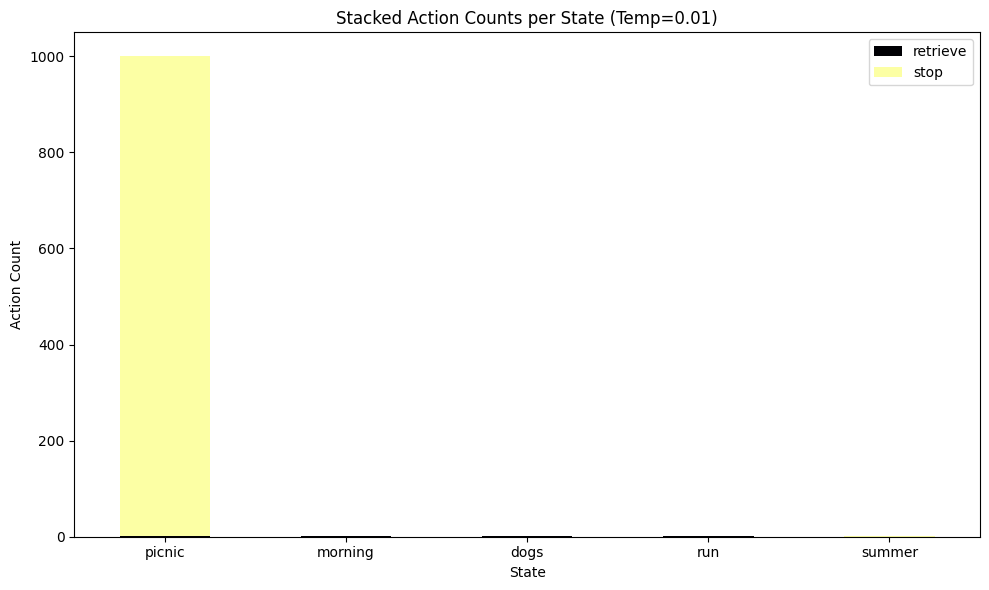

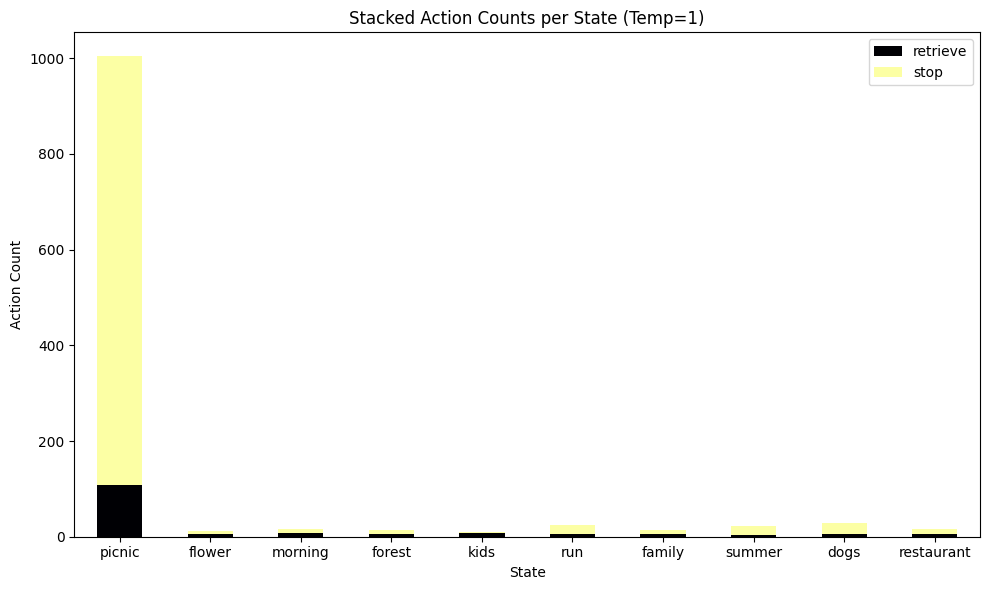

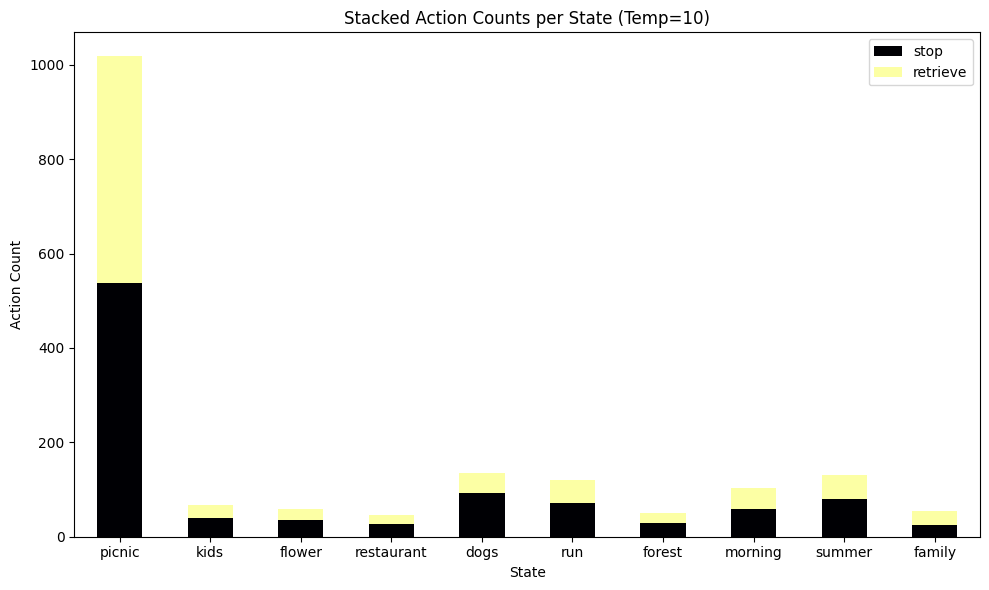

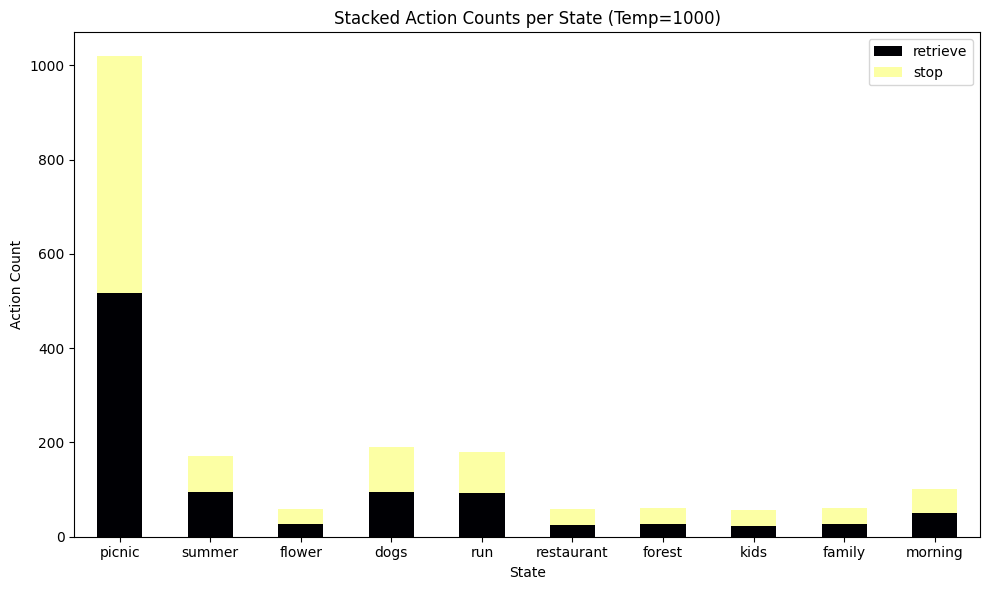

In [24]:
for temp in [0.01, 1, 10, 1000]:
    # nested dictionary: {state: {action: count}}
    trauma_count = defaultdict(float)
    target_count = defaultdict(float)
    q_trauma = 0
    q_target = 0


    # Run environment + agent
    e_test = Environment(w=100, d=0.9)
    agent_test = QAgent(temperature=temp, method="SARSA")
    n_trials = 1000
    q_history, all_history = run_trials(e_test, agent_test, n_trials)

    # Count (state, action) pairs
    for state, action in all_history:
        #state_action_count[(state, action)] += 1
        if state in test_dict["trauma"]:
            trauma_count[(state, action)] += 1
        if state in test_dict["target"]:
            target_count[(state, action)] += 1

    # Convert to DataFrame
    df_trauma = pd.DataFrame(trauma_count).fillna(0).astype(int).T # T means transposed
    df_target = pd.DataFrame(target_count).fillna(0).astype(int).T

    # Plot stacked bar chart
    ax = df_target.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="inferno")
    ax.set_title(f"Stacked Action Counts per State (Temp={temp})")
    ax.set_xlabel("State")
    ax.set_ylabel("Action Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

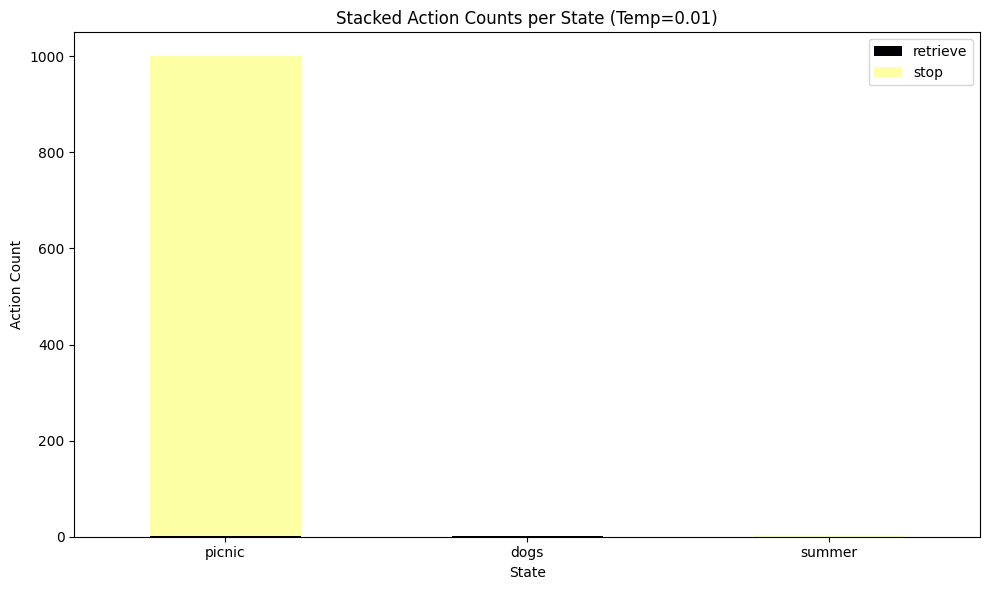

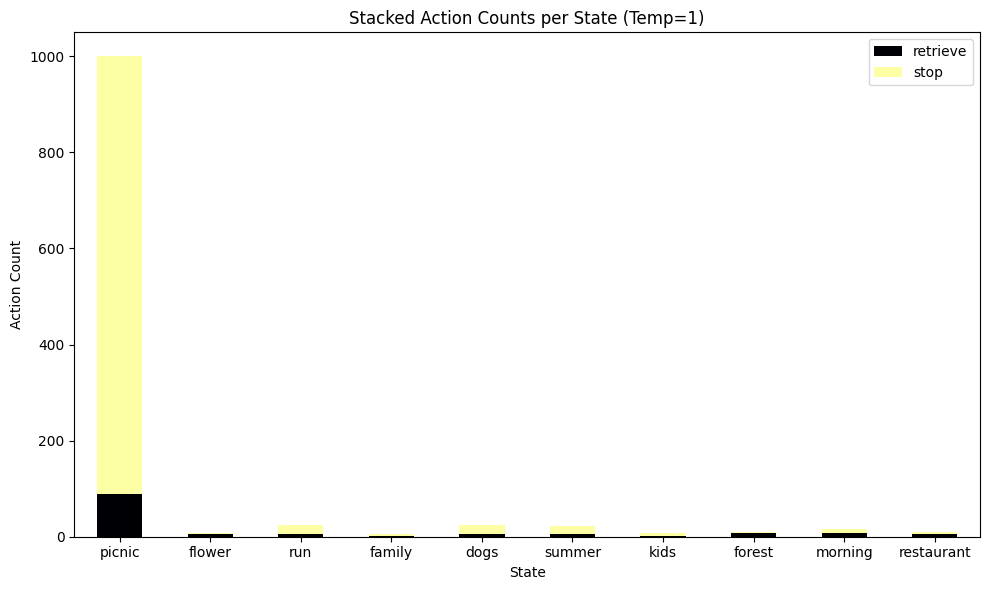

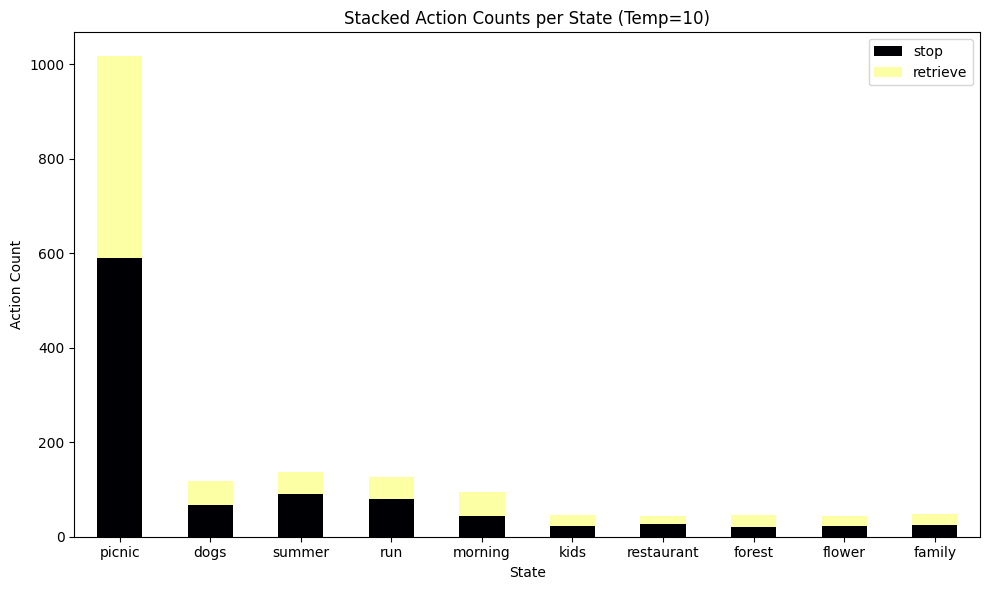

KeyboardInterrupt: 

In [37]:
for temp in [0.01, 1, 10, 1000]:
    # nested dictionary: {state: {action: count}}
    trauma_count = defaultdict(lambda: defaultdict(int))
    target_count = defaultdict(lambda: defaultdict(int))
    q_trauma = 0
    q_target = 0


    # Run environment + agent
    e_test = Environment(w=100, d=10)
    agent_test = QAgent(temperature=temp, method="SARSA")
    n_trials = 1000
    q_history, all_history = run_trials(e_test, agent_test, n_trials)

    # Count (state, action) pairs
    for state, action in all_history:
        #state_action_count[(state, action)] += 1
        if state in test_dict["trauma"]:
            trauma_count[state][action] += 1
        if state in test_dict["target"]:
            target_count[state][action] += 1
    for q_dict in q_history:
        # Iterate through the items of the current Q dictionary
        for (state, action), q in q_dict.items():
            if state in test_dict["trauma"]:
                q_trauma += q
            if state in test_dict["target"]:
                q_target += q


    # Convert to DataFrame
    df_trauma = pd.DataFrame(trauma_count).fillna(0).astype(int).T # T means transposed
    df_target = pd.DataFrame(target_count).fillna(0).astype(int).T

    # Plot stacked bar chart
    ax = df_target.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="inferno")
    ax.set_title(f"Stacked Action Counts per State (Temp={temp})")
    ax.set_xlabel("State")
    ax.set_ylabel("Action Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()






In [64]:
results = []
for temp in [1, 3, 5, 10, 20]:
    q_trauma = 0
    q_target = 0
    trauma_count = 0
    target_count = 0

    q_trauma_list = []
    q_target_list = []

    e_test = Environment(w=100,d=10)
    agent_test = QAgent(temperature=temp, method="SARSA")
    n_trials = 1000
    q_history, all_history = run_trials(e_test, agent_test, n_trials)

    for q_dict in q_history:
        for (state, action), q in q_dict.items():
            if state in test_dict["trauma"]:
                q_trauma += q
                trauma_count += 1
            if state in test_dict["target"]:
                q_target += q
                target_count += 1

    # Append after every trial
    avg_q_trauma = q_trauma / trauma_count if trauma_count > 0 else None
    avg_q_target = q_target / target_count if target_count > 0 else None
    q_trauma_list.append(avg_q_trauma)
    q_target_list.append(avg_q_target)

    df_temp = pd.DataFrame({

        "q_trauma": q_trauma_list,
        "q_target": q_target_list,
        "temperature": temp
    })
    df_temp.fillna(0, inplace=True)

    results.append(df_temp)

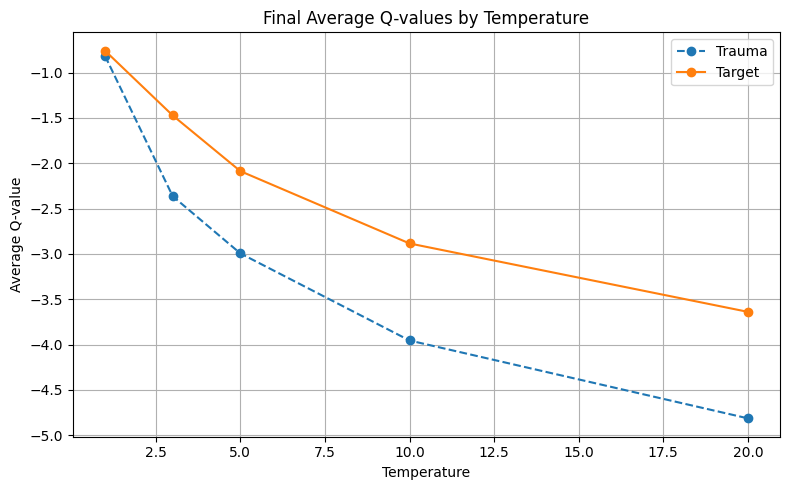

In [66]:
final_df = pd.concat(results)

# Replace NaNs with 0s to avoid plot issues
final_df.fillna(0, inplace=True)

# Group by temperature and get the last Q-value of each run (or use mean)
summary = final_df.groupby("temperature")[["q_trauma", "q_target"]].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(summary["temperature"], summary["q_trauma"], label="Trauma", linestyle='--', marker='o')
plt.plot(summary["temperature"], summary["q_target"], label="Target", marker='o')

plt.xlabel("Temperature")
plt.ylabel("Average Q-value")
plt.title("Final Average Q-values by Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
